# 🔬 BioSLATE Project — Phase 4: Benchmarking Synthetic Lethal Candidates Against Public Databases

**Author:** Faith Ogundimu  
**Date:** July 2025

**Notebook Purpose:**
This notebook benchmarks high-confidence synthetic lethal (SL) gene pairs—identified through CRISPR-based dependency analysis in HGSOC cell lines—against established SL databases, including **SynLethDB**, **ISLE**, and **DAISY**. This step helps distinguish novel interactions from previously reported or predicted SL relationships.

> **Context:** The SL hits assessed here were filtered based on global FDR < 0.1, negative dependency effect size (Cohen’s d < 0), and low wild-type essentiality (MeanEffect\_WT > –1). These form the final candidate list for therapeutic exploration and AI-based report generation.

---

### Objectives:

* Load the curated shortlist of **selective synthetic lethal gene pairs** from the BioSLATE Phase 3 screen.
* Parse and normalise gene–gene SL interaction data from multiple public databases:

  * **SynLethDB** (experimentally supported & predicted)
  * **ISLE** (computationally inferred SL from TCGA)
* For each biomarker–target gene pair:

  * Check if the interaction is reported in **any** public SL database (in either direction).
  * Annotate and rank hits by novelty and supporting evidence.

* Generate a benchmarking summary table indicating database overlap per pair.
* Export results for use in downstream visualisation, reporting, and translational prioritisation.


### SynLethDB

In [2]:
import pandas as pd

# Step 1: Load SL hits
my_hits = pd.read_csv("../results/CNA_quantitative_cluster_delta/potent_synthetic_lethal_hits_with_HGNC_ppi_validated.csv")

# Step 2: Load SynLethDB
synleth = pd.read_csv("../database_files/benchmarking/Human_SL.csv")  

# Step 3: Extract relevant columns and uppercase
synleth_pairs = synleth[["n1.name", "n2.name"]].dropna()
synleth_pairs.columns = ["Gene1", "Gene2"]
synleth_pairs = synleth_pairs.apply(lambda col: col.str.upper())

# Step 4: Match SL pairs in either direction
def is_in_synlethdb(row):
    g1, g2 = row["Biomarker_HGNC"], row["TargetGene_HGNC"]
    return (
        ((synleth_pairs["Gene1"] == g1) & (synleth_pairs["Gene2"] == g2)).any() or
        ((synleth_pairs["Gene1"] == g2) & (synleth_pairs["Gene2"] == g1)).any()
    )

my_hits["In_SynLethDB"] = my_hits.apply(is_in_synlethdb, axis=1)
my_hits["Novel?"] = ~my_hits["In_SynLethDB"]

# Step 5: Save output
my_hits.to_csv("../results/benchmark_vs_synlethdb.csv", index=False)

print("Done: benchmark_vs_synlethdb.csv created.")

Done: benchmark_vs_synlethdb.csv created.


### ISLE

In [3]:
import pandas as pd

# Step 1: Load SL hits
my_hits = pd.read_csv("../results/CNA_quantitative_cluster_delta/potent_synthetic_lethal_hits_with_HGNC_ppi_validated.csv")

# Step 2: Load ISLE SL data
isle = pd.read_csv("../database_files/benchmarking/ISLE_SL_pairs.csv") 

# Step 3: Extract gene columns and uppercase
isle_pairs = isle[["sr0.1", "sr0.2"]].dropna()
isle_pairs.columns = ["Gene1", "Gene2"]
isle_pairs = isle_pairs.apply(lambda col: col.str.upper())

# Step 4: Match in either direction
def is_in_isle(row):
    g1, g2 = row["Biomarker_HGNC"], row["TargetGene_HGNC"]
    return (
        ((isle_pairs["Gene1"] == g1) & (isle_pairs["Gene2"] == g2)).any() or
        ((isle_pairs["Gene1"] == g2) & (isle_pairs["Gene2"] == g1)).any()
    )

my_hits["In_ISLE"] = my_hits.apply(is_in_isle, axis=1)
my_hits["Novel?"] = ~my_hits["In_ISLE"]

# Step 5: Save result
my_hits.to_csv("../results/benchmark_vs_isle.csv", index=False)

print("Done: benchmark_vs_isle.csv created.")

Done: benchmark_vs_isle.csv created.


#### Merge

In [5]:
import pandas as pd
import os

# Load both benchmarking result files
synleth = pd.read_csv("../results/benchmark_vs_synlethdb.csv")
isle = pd.read_csv("../results/benchmark_vs_isle.csv")

# Merge ISLE into SynLethDB table
merged = synleth.merge(
    isle[["Biomarker_HGNC", "TargetGene_HGNC", "In_ISLE"]],
    on=["Biomarker_HGNC", "TargetGene_HGNC"],
    how="left"
)

# Remove 'Novel?' column (from SynLethDB)
if "Novel?" in merged.columns:
    merged.drop(columns=["Novel?"], inplace=True)

# Create final novelty column
merged["Novel?"] = ~(merged["In_SynLethDB"] | merged["In_ISLE"])

# Save final merged results
merged.to_csv("../results/benchmark_vs_synlethdb_and_isle.csv", index=False)
print("Done: Final merged benchmarking file saved.")

# Delete intermediate benchmarking files
try:
    os.remove("../results/benchmark_vs_synlethdb.csv")
    os.remove("../results/benchmark_vs_isle.csv")
    print("Intermediate files deleted.")
except FileNotFoundError:
    print("One or more files not found, skipping delete.")

Done: Final merged benchmarking file saved.
Intermediate files deleted.


### Overlap Barchart

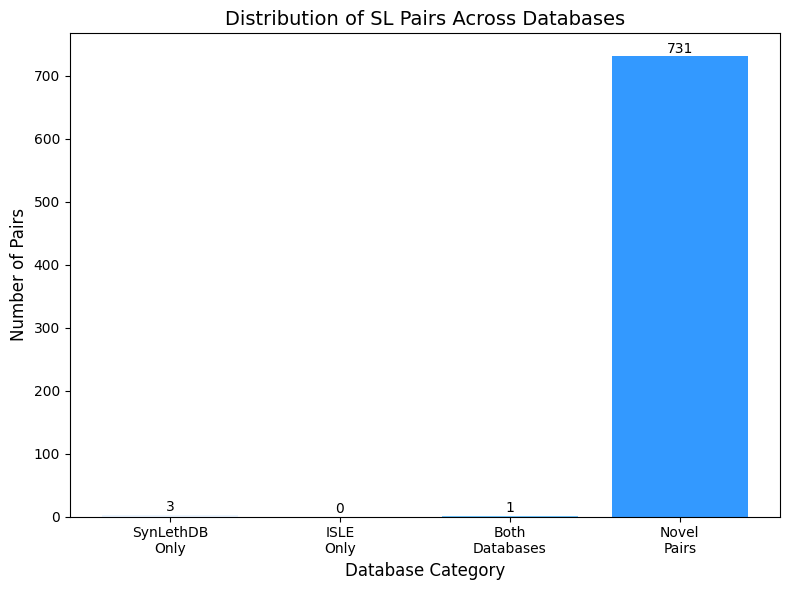

Total pairs analyzed: 735


In [6]:
import pandas as pd
from matplotlib import pyplot as plt

# Load data
merged = pd.read_csv("../results/benchmark_vs_synlethdb_and_isle.csv")

# Calculate counts
synleth_only = len(merged[merged['In_SynLethDB'] & ~merged['In_ISLE']])
isle_only = len(merged[~merged['In_SynLethDB'] & merged['In_ISLE']])
both_dbs = len(merged[merged['In_SynLethDB'] & merged['In_ISLE']])
novel = len(merged[~merged['In_SynLethDB'] & ~merged['In_ISLE']])

# Create bar chart
categories = ['SynLethDB\nOnly', 'ISLE\nOnly', 'Both\nDatabases', 'Novel\nPairs']
counts = [synleth_only, isle_only, both_dbs, novel]

# Define colors for each bar
colors = ['#e6f3ff', '#99d6ff', '#4db8ff', '#0080ff']  # Light to dark blues

plt.figure(figsize=(8, 6))
bars = plt.bar(categories, counts, color=colors, alpha=0.8)

# Add count labels on bars
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             str(count), ha='center', va='bottom')

plt.title("Distribution of SL Pairs Across Databases", fontsize=14)
plt.ylabel("Number of Pairs", fontsize=12)
plt.xlabel("Database Category", fontsize=12)
plt.tight_layout()
plt.show()

print(f"Total pairs analyzed: {sum(counts)}")